## Task 1: Daily Returns Analysis

In [10]:
import pandas as pd
import plotly.express as px

In [11]:
nav = pd.read_csv("data/processed/02_nav_history.csv")

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [12]:
nav.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  object 
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ MB


In [13]:
nav["date"] = pd.to_datetime(nav["date"])

In [14]:
nav.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[ns]
 2   nav        46000 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 1.1 MB


In [15]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

In [16]:
# Calculate daily return for each fund
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [17]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [18]:
fig = px.histogram(
    nav,
    x="daily_return",
    nbins=100,
    title="Distribution of Daily Returns"
)

fig.show()

### Observation

- Daily returns are concentrated around zero.
- Most NAV changes are small on a day-to-day basis.
- Large positive and negative daily returns occur less frequently.

In [19]:
nav.groupby("amfi_code")["date"].agg(["min", "max"])

,min,max
amfi_code,,
100016,2022-01-03,2026-05-29
100025,2022-01-03,2026-05-29
100033,2022-01-03,2026-05-29
101206,2022-01-03,2026-05-29
101207,2022-01-03,2026-05-29
101208,2022-01-03,2026-05-29
102885,2022-01-03,2026-05-29
102886,2022-01-03,2026-05-29
102887,2022-01-03,2026-05-29


## Task 2: CAGR Calculation

In [20]:
# Function to calculate CAGR

def calculate_cagr(start_nav, end_nav, years):
    cagr = (end_nav / start_nav) ** (1 / years) - 1
    return cagr

In [21]:
cagr_list = []

In [22]:
for fund in nav["amfi_code"].unique():

    fund_data = nav[nav["amfi_code"] == fund]

    fund_data = fund_data.sort_values("date")

    end_date = fund_data["date"].max()
    end_nav = fund_data.iloc[-1]["nav"]

    # 1 Year CAGR
    start_1 = end_date - pd.DateOffset(years=1)
    data_1 = fund_data[fund_data["date"] >= start_1]

    if len(data_1) > 0:
        start_nav_1 = data_1.iloc[0]["nav"]
        cagr_1 = calculate_cagr(start_nav_1, end_nav, 1)
    else:
        cagr_1 = None

    # 3 Year CAGR
    start_3 = end_date - pd.DateOffset(years=3)
    data_3 = fund_data[fund_data["date"] >= start_3]

    if len(data_3) > 0:
        start_nav_3 = data_3.iloc[0]["nav"]
        cagr_3 = calculate_cagr(start_nav_3, end_nav, 3)
    else:
        cagr_3 = None

    # 5 Year CAGR
    start_5 = end_date - pd.DateOffset(years=5)
    data_5 = fund_data[fund_data["date"] >= start_5]

    if len(data_5) > 1200:
        start_nav_5 = data_5.iloc[0]["nav"]
        cagr_5 = calculate_cagr(start_nav_5, end_nav, 5)
    else:
        cagr_5 = None

    cagr_list.append({
        "amfi_code": fund,
        "cagr_1yr": cagr_1,
        "cagr_3yr": cagr_3,
        "cagr_5yr": cagr_5
    })

In [23]:
cagr_table = pd.DataFrame(cagr_list)

cagr_table.head()

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,-0.022243,0.012926,None
1,100025,0.037050,0.039164,None
2,100033,0.532324,0.324425,None
3,101206,0.479241,0.289677,None
4,101207,-0.239860,-0.041524,None


In [24]:
cagr_table["cagr_1yr"] = cagr_table["cagr_1yr"] * 100
cagr_table["cagr_3yr"] = cagr_table["cagr_3yr"] * 100
cagr_table["cagr_5yr"] = cagr_table["cagr_5yr"] * 100

cagr_table.head()

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,-2.224271,1.292649,NaN
1,100025,3.704969,3.916390,NaN
2,100033,53.232396,32.442459,NaN
3,101206,47.924120,28.967695,NaN
4,101207,-23.986032,-4.152381,NaN


### Observation

- CAGR was calculated for all mutual fund schemes.
- One-year and three-year CAGR values were successfully computed.
- Five-year CAGR is unavailable because the dataset does not contain a complete five-year history.

## Task 3: Sharpe Ratio

In [31]:
sharpe_list = []

In [32]:
rf = 0.065
daily_rf = rf / 252

In [33]:
rf = 0.065
daily_rf = rf / 252

daily_rf

0.00025793650793650796

In [34]:
for fund in nav["amfi_code"].unique():

    fund_data = nav[nav["amfi_code"] == fund]

    avg_return = fund_data["daily_return"].mean()

    std_return = fund_data["daily_return"].std()

    sharpe = ((avg_return - daily_rf) / std_return) * (252 ** 0.5)

    sharpe_list.append({
        "amfi_code": fund,
        "sharpe_ratio": sharpe
    })

In [35]:
sharpe_table = pd.DataFrame(sharpe_list)

sharpe_table.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [36]:
sharpe_table = sharpe_table.sort_values(
    by="sharpe_ratio",
    ascending=False
)

sharpe_table.reset_index(drop=True, inplace=True)

sharpe_table.head(10)

,amfi_code,sharpe_ratio
0,148567,1.448291
1,120843,1.306744
2,148569,1.234930
3,119551,1.208267
4,120505,1.180101
5,149323,1.132122
6,100033,1.093699
7,118632,1.081659
8,101206,1.027213
9,120504,1.026524


### Observation

- Sharpe Ratio was calculated for all mutual fund schemes.
- Funds with higher Sharpe Ratios generated better risk-adjusted returns.
- The ranking helps identify funds that provided higher returns relative to their risk.

## Task 4: Sortino Ratio

In [42]:
for fund in nav["amfi_code"].unique():

    fund_data = nav[nav["amfi_code"] == fund]

    avg_return = fund_data["daily_return"].mean()

    # Keep only negative daily returns
    downside_returns = fund_data[fund_data["daily_return"] < 0]["daily_return"]

    downside_std = downside_returns.std()

    if downside_std > 0:
        sortino = ((avg_return - daily_rf) / downside_std) * (252 ** 0.5)
    else:
        sortino = None

    sortino_list.append({
        "amfi_code": fund,
        "sortino_ratio": sortino
    })

In [43]:
sortino_list = []

In [48]:
sortino_table = pd.DataFrame(sortino_list)

sortino_table.head()

""


In [50]:
sortino_table.columns

RangeIndex(start=0, stop=0, step=1)

In [51]:
sortino_table.head()

""


In [52]:
len(sortino_list)

0

In [53]:
nav["daily_return"].isna().sum()

np.int64(40)

In [54]:
nav["amfi_code"].nunique()

40

In [55]:
fund = nav["amfi_code"].unique()[0]

fund_data = nav[nav["amfi_code"] == fund]

fund_data.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [56]:
fund = nav["amfi_code"].unique()[0]

fund_data = nav[nav["amfi_code"] == fund]

returns = fund_data["daily_return"].dropna()

downside_returns = returns[returns < 0]

print("Average Return:", returns.mean())
print("Downside Std:", downside_returns.std())
print("Negative Return Days:", len(downside_returns))

Average Return: 0.00014159930699210853
Downside Std: 0.005260815192179734
Negative Return Days: 579


In [57]:
# Risk-free rate (daily)
daily_rf = 0.065 / 252

sortino_list = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[nav["amfi_code"] == fund]

    returns = fund_data["daily_return"].dropna()

    avg_return = returns.mean()

    downside_returns = returns[returns < 0]

    downside_std = downside_returns.std()

    if downside_std > 0:
        sortino = ((avg_return - daily_rf) / downside_std) * (252 ** 0.5)
    else:
        sortino = None

    sortino_list.append({
        "amfi_code": fund,
        "sortino_ratio": sortino
    })

sortino_table = pd.DataFrame(sortino_list)

sortino_table = sortino_table.sort_values(
    by="sortino_ratio",
    ascending=False
)

sortino_table.reset_index(drop=True, inplace=True)

sortino_table.head(10)

,amfi_code,sortino_ratio
0,148567,2.385644
1,120843,2.364320
2,148569,2.146914
3,119551,2.140267
4,120505,2.029353
5,149323,1.875101
6,118632,1.850133
7,100033,1.829134
8,120504,1.805294
9,101206,1.799563


In [58]:
len(sortino_list)

40

In [59]:
sortino_table.head()

,amfi_code,sortino_ratio
0,148567,2.385644
1,120843,2.364320
2,148569,2.146914
3,119551,2.140267
4,120505,2.029353


In [61]:
benchmark = pd.read_csv("data/raw/10_benchmark_indices.csv")

In [62]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [63]:
benchmark.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8050 entries, 0 to 8049
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         8050 non-null   object 
 1   index_name   8050 non-null   object 
 2   close_value  8050 non-null   float64
dtypes: float64(1), object(2)
memory usage: 188.8+ KB


## Task 5: Alpha and Beta

In [95]:
# Convert date to datetime
benchmark["date"] = pd.to_datetime(benchmark["date"])

# Check available indexes
print(benchmark["index_name"].unique())

['NIFTY50' 'NIFTY100' 'NIFTY_MIDCAP150' 'BSE_SMALLCAP' 'NIFTY500'
 'CRISIL_LIQUID' 'CRISIL_GILT']


In [96]:
# Select NIFTY 100
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

# Sort by date
nifty100 = nifty100.sort_values("date")

# Calculate daily returns
nifty100["benchmark_return"] = (
    nifty100["close_value"] /
    nifty100["close_value"].shift(1)
) - 1

# Remove first missing return
nifty100 = nifty100.dropna(
    subset=["benchmark_return"]
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150
1155,2022-01-10,NIFTY100,17516.51,-0.008351


In [97]:
print(nifty100["benchmark_return"].describe())

print(
    "Missing benchmark returns:",
    nifty100["benchmark_return"].isna().sum()
)

count    1149.000000
mean        0.000122
std         0.008119
min        -0.026873
25%        -0.005385
50%        -0.000112
75%         0.005456
max         0.026795
Name: benchmark_return, dtype: float64
Missing benchmark returns: 0


In [98]:
from scipy.stats import linregress

In [99]:
alpha_beta_list = []

In [100]:
for fund in nav["amfi_code"].unique():

    # Select one fund
    fund_data = nav[
        nav["amfi_code"] == fund
    ].copy()

    # Select required columns
    fund_data = fund_data[
        ["date", "daily_return"]
    ]

    # Merge fund returns with NIFTY 100 returns
    merged = pd.merge(
        fund_data,
        nifty100[
            ["date", "benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    # Remove missing values
    merged = merged.dropna(
        subset=[
            "daily_return",
            "benchmark_return"
        ]
    )

    # OLS regression
    regression = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    # Beta = slope
    beta = regression.slope

    # Annualized Alpha
    alpha = regression.intercept * 252

    alpha_beta_list.append({
        "amfi_code": fund,
        "alpha": alpha,
        "beta": beta
    })

In [101]:
alpha_beta_table = pd.DataFrame(
    alpha_beta_list
)

alpha_beta_table.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [102]:
print(nav.columns)

Index(['amfi_code', 'date', 'nav', 'daily_return'], dtype='object')


In [103]:
print([x for x in globals() if isinstance(globals()[x], pd.DataFrame)])

['_', '__', '___', 'nav', '_2', '_7', '_11', '_16', '_19', 'fund_data', 'data_1', 'data_3', 'data_5', 'cagr_table', '_23', '_24', 'sharpe_table', '_29', '_30', '_35', '_36', 'sortino_table', '_40', '_41', '_44', '_48', '_51', '_55', '_57', '_59', 'benchmark', '_62', 'nifty100', '_65', 'merged', 'alpha_beta_table', '_70', '_74', '_76', 'beta_ranked', '_77', 'test_fund', 'test_merged', '_88', '_92', '_96', '_101']


In [104]:
alpha_beta_table = alpha_beta_table.sort_values(
    by="alpha",
    ascending=False
)

alpha_beta_table.reset_index(
    drop=True,
    inplace=True
)

alpha_beta_table.head(10)

,amfi_code,alpha,beta
0,119598,0.303370,-0.023196
1,149324,0.300579,0.011455
2,120505,0.292636,0.000549
3,148569,0.282704,0.018134
4,120843,0.273305,-0.022830
5,100033,0.271954,0.005104
6,148567,0.269838,0.023684
7,149323,0.265986,-0.002523
8,119094,0.260767,-0.066265
9,119551,0.232010,-0.031751


In [105]:
beta_ranked = alpha_beta_table.sort_values(
    by="beta",
    ascending=False
)

beta_ranked.reset_index(
    drop=True,
    inplace=True
)

beta_ranked.head(10)

,amfi_code,alpha,beta
0,118634,0.175007,0.103497
1,119599,0.048824,0.062002
2,125497,0.177298,0.048820
3,120506,0.162539,0.041896
4,120841,0.130429,0.036356
5,119093,0.082328,0.025883
6,148567,0.269838,0.023684
7,101206,0.213998,0.021086
8,148569,0.282704,0.018134
9,120842,0.078044,0.018057


In [106]:
print("Number of funds:", len(alpha_beta_table))

print(
    "Missing Alpha:",
    alpha_beta_table["alpha"].isna().sum()
)

print(
    "Missing Beta:",
    alpha_beta_table["beta"].isna().sum()
)

Number of funds: 40
Missing Alpha: 0
Missing Beta: 0


In [107]:
print(merged.shape)

print(
    merged[
        ["date", "daily_return", "benchmark_return"]
    ].head(10)
)

print(
    merged[
        ["daily_return", "benchmark_return"]
    ].corr()
)

(1149, 3)
        date  daily_return  benchmark_return
0 2022-01-04     -0.010498         -0.013540
1 2022-01-05     -0.002593          0.004003
2 2022-01-06     -0.008382         -0.002935
3 2022-01-07      0.011680          0.006150
4 2022-01-10      0.001356         -0.008351
5 2022-01-11     -0.002607          0.004942
6 2022-01-12     -0.000262          0.009128
7 2022-01-13      0.018590          0.003746
8 2022-01-14     -0.006717         -0.014098
9 2022-01-17     -0.018998          0.020825
                  daily_return  benchmark_return
daily_return          1.000000          0.005944
benchmark_return      0.005944          1.000000


In [108]:
print(merged[["daily_return", "benchmark_return"]].describe())

       daily_return  benchmark_return
count   1149.000000       1149.000000
mean       0.001194          0.000122
std        0.015648          0.008119
min       -0.048870         -0.026873
25%       -0.008741         -0.005385
50%        0.000987         -0.000112
75%        0.011440          0.005456
max        0.048490          0.026795


In [109]:
print("Fund return standard deviation:",
      merged["daily_return"].std())

print("NIFTY 100 return standard deviation:",
      merged["benchmark_return"].std())

Fund return standard deviation: 0.01564785832374583
NIFTY 100 return standard deviation: 0.008119419678050336


In [110]:
test_fund = nav[nav["amfi_code"] == 119551].copy()

test_merged = pd.merge(
    test_fund[["date", "daily_return"]],
    nifty100[["date", "benchmark_return"]],
    on="date",
    how="inner"
).dropna()

test_regression = linregress(
    test_merged["benchmark_return"],
    test_merged["daily_return"]
)

print("Observations:", len(test_merged))
print("Correlation:",
      test_merged["daily_return"].corr(
          test_merged["benchmark_return"]
      ))
print("Beta:", test_regression.slope)
print("Annualized Alpha:",
      test_regression.intercept * 252)

Observations: 1149
Correlation: -0.02978219078463307
Beta: -0.03175144113890976
Annualized Alpha: 0.23201007160635082


In [111]:
# Sort by fund and date
nav = nav.sort_values(
    ["amfi_code", "date"]
).copy()

# Calculate daily return separately for each fund
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

# Check the result
print(nav.head(10))

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210
5     100016 2022-01-10  510.7136     -0.008639
6     100016 2022-01-11  513.5542      0.005562
7     100016 2022-01-12  512.3195     -0.002404
8     100016 2022-01-13  510.2445     -0.004050
9     100016 2022-01-14  514.3636      0.008073


In [112]:
print(
    nav.groupby("amfi_code")["daily_return"]
       .count()
       .describe()
)

count      40.0
mean     1149.0
std         0.0
min      1149.0
25%      1149.0
50%      1149.0
75%      1149.0
max      1149.0
Name: daily_return, dtype: float64


In [113]:
alpha_beta_list = []

In [114]:
for fund in nav["amfi_code"].unique():

    # Select one fund
    fund_data = nav[
        nav["amfi_code"] == fund
    ].copy()

    # Select required columns
    fund_data = fund_data[
        ["date", "daily_return"]
    ]

    # Merge with NIFTY 100 returns
    merged = pd.merge(
        fund_data,
        nifty100[
            ["date", "benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    # Remove missing values
    merged = merged.dropna(
        subset=[
            "daily_return",
            "benchmark_return"
        ]
    )

    # OLS regression
    regression = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    # Beta = slope
    beta = regression.slope

    # Annualized Alpha
    alpha = regression.intercept * 252

    alpha_beta_list.append({
        "amfi_code": fund,
        "alpha": alpha,
        "beta": beta
    })

In [115]:
alpha_beta_table = pd.DataFrame(
    alpha_beta_list
)

alpha_beta_table.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [116]:
print("Number of funds:", len(alpha_beta_table))

print(
    "Missing Alpha:",
    alpha_beta_table["alpha"].isna().sum()
)

print(
    "Missing Beta:",
    alpha_beta_table["beta"].isna().sum()
)

Number of funds: 40
Missing Alpha: 0
Missing Beta: 0


In [117]:
from scipy.stats import linregress

test_fund = nav[nav["amfi_code"] == 119551].copy()

test_merged = pd.merge(
    test_fund[["date", "daily_return"]],
    nifty100[["date", "benchmark_return"]],
    on="date",
    how="inner"
).dropna()

test_regression = linregress(
    test_merged["benchmark_return"],
    test_merged["daily_return"]
)

print("Observations:", len(test_merged))
print("Correlation:",
      test_merged["daily_return"].corr(
          test_merged["benchmark_return"]
      ))
print("Beta:", test_regression.slope)
print("Annualized Alpha:",
      test_regression.intercept * 252)

Observations: 1149
Correlation: -0.02978219078463307
Beta: -0.03175144113890976
Annualized Alpha: 0.23201007160635082


In [118]:
print(
    nav[nav["amfi_code"] == 119551]["daily_return"].describe()
)

count    1149.000000
mean        0.000917
std         0.008656
min        -0.027680
25%        -0.004866
50%         0.000940
75%         0.006442
max         0.035096
Name: daily_return, dtype: float64


In [119]:
alpha_beta_table = pd.DataFrame(alpha_beta_list)

alpha_beta_table = alpha_beta_table.sort_values(
    by="alpha",
    ascending=False
)

alpha_beta_table.reset_index(
    drop=True,
    inplace=True
)

alpha_beta_table.head(10)

,amfi_code,alpha,beta
0,119598,0.303370,-0.023196
1,149324,0.300579,0.011455
2,120505,0.292636,0.000549
3,148569,0.282704,0.018134
4,120843,0.273305,-0.022830
5,100033,0.271954,0.005104
6,148567,0.269838,0.023684
7,149323,0.265986,-0.002523
8,119094,0.260767,-0.066265
9,119551,0.232010,-0.031751


In [120]:
print("Number of funds:", len(alpha_beta_table))

print(
    "Missing Alpha:",
    alpha_beta_table["alpha"].isna().sum()
)

print(
    "Missing Beta:",
    alpha_beta_table["beta"].isna().sum()
)

Number of funds: 40
Missing Alpha: 0
Missing Beta: 0


In [121]:
alpha_beta_table.to_csv(
    "alpha_beta.csv",
    index=False
)

print("alpha_beta.csv created successfully!")

alpha_beta.csv created successfully!


### Observation

- Alpha and Beta were calculated for all 40 mutual fund schemes using NIFTY 100 as the benchmark.
- OLS linear regression was performed using daily fund returns and NIFTY 100 daily returns.
- Beta measures the sensitivity of each fund to movements in NIFTY 100.
- Alpha represents the annualized excess return after accounting for benchmark exposure.
- Positive Alpha indicates better performance relative to the return predicted by the benchmark exposure.
- Beta values vary across the funds depending on their relationship with NIFTY 100.

## Task 6: Maximum Drawdown

In [131]:
drawdown_list = []

In [132]:
for fund in nav["amfi_code"].unique():

    # Select one fund
    fund_data = nav[
        nav["amfi_code"] == fund
    ].copy()

    # Sort by date
    fund_data = fund_data.sort_values("date")

    # Calculate running maximum NAV
    fund_data["running_max"] = (
        fund_data["nav"].cummax()
    )

    # Calculate drawdown
    fund_data["drawdown"] = (
        fund_data["nav"] /
        fund_data["running_max"]
    ) - 1

    # Find maximum drawdown
    max_drawdown = fund_data["drawdown"].min()

    # Date of maximum drawdown
    max_dd_date = fund_data.loc[
        fund_data["drawdown"].idxmin(),
        "date"
    ]

    drawdown_list.append({
        "amfi_code": fund,
        "max_drawdown": max_drawdown,
        "max_drawdown_date": max_dd_date
    })

In [133]:
drawdown_table = pd.DataFrame(
    drawdown_list
)

drawdown_table.head()

,amfi_code,max_drawdown,max_drawdown_date
0,100016,-0.247344,2022-09-15
1,100025,-0.043083,2023-07-28
2,100033,-0.162172,2022-05-12
3,101206,-0.112916,2023-07-05
4,101207,-0.354469,2026-05-11


In [134]:
drawdown_table["max_drawdown_pct"] = (
    drawdown_table["max_drawdown"] * 100
)

In [135]:
drawdown_table.head()

,amfi_code,max_drawdown,max_drawdown_date,max_drawdown_pct
0,100016,-0.247344,2022-09-15,-24.734441
1,100025,-0.043083,2023-07-28,-4.308264
2,100033,-0.162172,2022-05-12,-16.217209
3,101206,-0.112916,2023-07-05,-11.291596
4,101207,-0.354469,2026-05-11,-35.446916


In [136]:
worst_drawdowns = drawdown_table.sort_values(
    by="max_drawdown",
    ascending=True
)

worst_drawdowns.reset_index(
    drop=True,
    inplace=True
)

worst_drawdowns.head(10)

,amfi_code,max_drawdown,max_drawdown_date,max_drawdown_pct
0,119599,-0.525742,2025-10-28,-52.574221
1,119095,-0.516778,2026-05-11,-51.677754
2,101207,-0.354469,2026-05-11,-35.446916
3,149324,-0.311719,2025-01-03,-31.171900
4,119598,-0.287060,2025-05-14,-28.706006
5,102886,-0.280011,2026-04-27,-28.001124
6,100016,-0.247344,2022-09-15,-24.734441
7,120842,-0.240035,2024-10-17,-24.003511
8,118634,-0.233449,2026-02-20,-23.344886
9,119093,-0.217514,2023-05-22,-21.751396


In [137]:
print(
    "Number of funds:",
    len(drawdown_table)
)

print(
    "Missing Maximum Drawdown:",
    drawdown_table["max_drawdown"].isna().sum()
)

Number of funds: 40
Missing Maximum Drawdown: 0


In [138]:
drawdown_list = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[
        nav["amfi_code"] == fund
    ].copy()

    fund_data = fund_data.sort_values("date")

    # Running maximum
    fund_data["running_max"] = (
        fund_data["nav"].cummax()
    )

    # Drawdown
    fund_data["drawdown"] = (
        fund_data["nav"] /
        fund_data["running_max"]
    ) - 1

    # Maximum drawdown row
    bottom_idx = fund_data["drawdown"].idxmin()

    bottom_date = fund_data.loc[
        bottom_idx,
        "date"
    ]

    max_drawdown = fund_data.loc[
        bottom_idx,
        "drawdown"
    ]

    # NAV at the bottom
    bottom_nav = fund_data.loc[
        bottom_idx,
        "nav"
    ]

    # Peak NAV before the bottom
    peak_nav = fund_data.loc[
        :bottom_idx,
        "nav"
    ].max()

    # Date of peak NAV
    peak_idx = fund_data.loc[
        :bottom_idx,
        "nav"
    ].idxmax()

    peak_date = fund_data.loc[
        peak_idx,
        "date"
    ]

    drawdown_list.append({
        "amfi_code": fund,
        "max_drawdown": max_drawdown,
        "peak_date": peak_date,
        "bottom_date": bottom_date,
        "peak_nav": peak_nav,
        "bottom_nav": bottom_nav
    })

drawdown_table = pd.DataFrame(drawdown_list)

drawdown_table.head()

,amfi_code,max_drawdown,peak_date,bottom_date,peak_nav,bottom_nav
0,100016,-0.247344,2022-03-30,2022-09-15,546.3002,411.1759
1,100025,-0.043083,2023-05-23,2023-07-28,28.7494,27.5108
2,100033,-0.162172,2022-03-11,2022-05-12,111.6641,93.5553
3,101206,-0.112916,2023-04-24,2023-07-05,370.0026,328.2234
4,101207,-0.354469,2024-11-21,2026-05-11,80.3517,51.8695


In [139]:
drawdown_table = drawdown_table.sort_values(
    by="max_drawdown",
    ascending=True
)

drawdown_table.reset_index(
    drop=True,
    inplace=True
)

drawdown_table.head(10)

,amfi_code,max_drawdown,peak_date,bottom_date,peak_nav,bottom_nav
0,119599,-0.525742,2023-01-17,2025-10-28,165.7647,78.6152
1,119095,-0.516778,2025-05-22,2026-05-11,106.8214,51.6185
2,101207,-0.354469,2024-11-21,2026-05-11,80.3517,51.8695
3,149324,-0.311719,2024-05-03,2025-01-03,174.4645,120.0806
4,119598,-0.287060,2024-08-28,2025-05-14,225.2452,160.5863
5,102886,-0.280011,2025-01-07,2026-04-27,169.8164,122.2659
6,100016,-0.247344,2022-03-30,2022-09-15,546.3002,411.1759
7,120842,-0.240035,2023-11-09,2024-10-17,80.0837,60.8608
8,118634,-0.233449,2025-04-09,2026-02-20,126.7224,97.1392
9,119093,-0.217514,2022-02-24,2023-05-22,42.2166,33.0339


In [140]:
drawdown_table["drawdown_days"] = (
    pd.to_datetime(drawdown_table["bottom_date"]) -
    pd.to_datetime(drawdown_table["peak_date"])
).dt.days

drawdown_table.head()

,amfi_code,max_drawdown,peak_date,bottom_date,peak_nav,bottom_nav,drawdown_days
0,119599,-0.525742,2023-01-17,2025-10-28,165.7647,78.6152,1015
1,119095,-0.516778,2025-05-22,2026-05-11,106.8214,51.6185,354
2,101207,-0.354469,2024-11-21,2026-05-11,80.3517,51.8695,536
3,149324,-0.311719,2024-05-03,2025-01-03,174.4645,120.0806,245
4,119598,-0.287060,2024-08-28,2025-05-14,225.2452,160.5863,259


In [141]:
drawdown_table.to_csv(
    "maximum_drawdown.csv",
    index=False
)

print("maximum_drawdown.csv created successfully!")

maximum_drawdown.csv created successfully!


### Observation

- Maximum Drawdown was calculated for all 40 mutual fund schemes.
- Running maximum NAV was used to identify the largest decline from a previous peak.
- The peak date, bottom date, and drawdown duration were identified for each fund.
- The worst-performing funds experienced drawdowns exceeding 50%, indicating significant declines from their historical peaks.
- Maximum Drawdown helps evaluate downside risk and capital preservation across mutual fund schemes.

In [142]:
print(performance.columns.tolist())

NameError: name 'performance' is not defined

In [143]:
%whos DataFrame

Variable           Type         Data/Info
-----------------------------------------
alpha_beta_table   DataFrame    Shape: (40, 3)
benchmark          DataFrame    Shape: (8050, 3)
beta_ranked        DataFrame    Shape: (40, 3)
cagr_table         DataFrame    Shape: (40, 4)
data_1             DataFrame    Shape: (262, 4)
data_3             DataFrame    Shape: (785, 4)
data_5             DataFrame    Shape: (1150, 4)
drawdown_table     DataFrame    Shape: (40, 7)
fund_data          DataFrame    Shape: (1150, 6)
merged             DataFrame    Shape: (1149, 3)
nav                DataFrame    Shape: (46000, 4)
nifty100           DataFrame    Shape: (1149, 4)
sharpe_table       DataFrame    Shape: (40, 2)
sortino_table      DataFrame    Shape: (40, 2)
test_fund          DataFrame    Shape: (1150, 4)
test_merged        DataFrame    Shape: (1149, 3)
worst_drawdowns    DataFrame    Shape: (40, 4)


In [144]:
print("CAGR:", cagr_table.columns.tolist())
print("Sharpe:", sharpe_table.columns.tolist())
print("Alpha/Beta:", alpha_beta_table.columns.tolist())
print("Drawdown:", drawdown_table.columns.tolist())
print("Fund:", fund_data.columns.tolist())

CAGR: ['amfi_code', 'cagr_1yr', 'cagr_3yr', 'cagr_5yr']
Sharpe: ['amfi_code', 'sharpe_ratio']
Alpha/Beta: ['amfi_code', 'alpha', 'beta']
Drawdown: ['amfi_code', 'max_drawdown', 'peak_date', 'bottom_date', 'peak_nav', 'bottom_nav', 'drawdown_days']
Fund: ['amfi_code', 'date', 'nav', 'daily_return', 'running_max', 'drawdown']


In [145]:
print([name for name in globals() if 'expense' in name.lower()])

[]


In [146]:
%whos DataFrame

Variable           Type         Data/Info
-----------------------------------------
alpha_beta_table   DataFrame    Shape: (40, 3)
benchmark          DataFrame    Shape: (8050, 3)
beta_ranked        DataFrame    Shape: (40, 3)
cagr_table         DataFrame    Shape: (40, 4)
data_1             DataFrame    Shape: (262, 4)
data_3             DataFrame    Shape: (785, 4)
data_5             DataFrame    Shape: (1150, 4)
drawdown_table     DataFrame    Shape: (40, 7)
fund_data          DataFrame    Shape: (1150, 6)
merged             DataFrame    Shape: (1149, 3)
nav                DataFrame    Shape: (46000, 4)
nifty100           DataFrame    Shape: (1149, 4)
sharpe_table       DataFrame    Shape: (40, 2)
sortino_table      DataFrame    Shape: (40, 2)
test_fund          DataFrame    Shape: (1150, 4)
test_merged        DataFrame    Shape: (1149, 3)
worst_drawdowns    DataFrame    Shape: (40, 4)


In [147]:
import pandas as pd
import os

# Find scheme_performance.csv
for root, dirs, files in os.walk("."):
    for file in files:
        if file.lower() == "scheme_performance.csv":
            print(os.path.join(root, file))

In [150]:
expense_data = pd.read_csv("./data/processed/09_scheme_performance.csv")

print(expense_data.columns.tolist())
print(expense_data.head())
print(expense_data.shape)

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']
   amfi_code                                   scheme_name       fund_house  \
0     119551     SBI Bluechip Fund - Regular Plan - Growth  SBI Mutual Fund   
1     119552      SBI Bluechip Fund - Direct Plan - Growth  SBI Mutual Fund   
2     119598    SBI Small Cap Fund - Regular Plan - Growth  SBI Mutual Fund   
3     119599     SBI Small Cap Fund - Direct Plan - Growth  SBI Mutual Fund   
4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth  SBI Mutual Fund   

    category     plan  return_1yr_pct  return_3yr_pct  return_5yr_pct  \
0  Large Cap  Regular           12.42           12.36           14.45   
1  Large Cap   Direct           15.25           11.30           14.23   
2  Small 

In [149]:
import os

matches = []

for root, dirs, files in os.walk("."):
    for file in files:
        if "performance" in file.lower() and file.lower().endswith(".csv"):
            matches.append(os.path.join(root, file))

print("Files found:")
for file in matches:
    print(file)

Files found:
.\data\processed\09_scheme_performance.csv
.\data\raw\07_scheme_performance.csv


In [151]:
# Task 7: Fund Scorecard

scorecard = cagr_table[['amfi_code', 'cagr_3yr']].copy()

scorecard = scorecard.merge(
    sharpe_table[['amfi_code', 'sharpe_ratio']],
    on='amfi_code',
    how='inner'
)

scorecard = scorecard.merge(
    alpha_beta_table[['amfi_code', 'alpha']],
    on='amfi_code',
    how='inner'
)

scorecard = scorecard.merge(
    drawdown_table[['amfi_code', 'max_drawdown']],
    on='amfi_code',
    how='inner'
)

scorecard = scorecard.merge(
    expense_data[['amfi_code', 'expense_ratio_pct']],
    on='amfi_code',
    how='inner'
)

print(scorecard.shape)
print(scorecard.head())

(40, 6)
   amfi_code   cagr_3yr  sharpe_ratio     alpha  max_drawdown  \
0     100016   1.292649     -0.201517  0.037476     -0.247344   
1     100025   3.916390     -0.567095  0.042818     -0.043083   
2     100033  32.442459      1.093699  0.271954     -0.162172   
3     101206  28.967695      1.027213  0.213998     -0.112916   
4     101207  -4.152381      0.162661  0.108971     -0.354469   

   expense_ratio_pct  
0               1.55  
1               0.56  
2               1.38  
3               1.60  
4               1.53  


In [152]:
# Rank each metric

# Higher 3-year CAGR = better
scorecard['return_rank'] = scorecard['cagr_3yr'].rank(
    ascending=False,
    method='min'
)

# Higher Sharpe = better
scorecard['sharpe_rank'] = scorecard['sharpe_ratio'].rank(
    ascending=False,
    method='min'
)

# Higher Alpha = better
scorecard['alpha_rank'] = scorecard['alpha'].rank(
    ascending=False,
    method='min'
)

# Lower Expense Ratio = better
scorecard['expense_rank'] = scorecard['expense_ratio_pct'].rank(
    ascending=True,
    method='min'
)

# Maximum Drawdown:
# Example: -10% is better than -30%
# Therefore less negative = better
scorecard['drawdown_rank'] = scorecard['max_drawdown'].rank(
    ascending=False,
    method='min'
)

print(scorecard.head())

   amfi_code   cagr_3yr  sharpe_ratio     alpha  max_drawdown  \
0     100016   1.292649     -0.201517  0.037476     -0.247344   
1     100025   3.916390     -0.567095  0.042818     -0.043083   
2     100033  32.442459      1.093699  0.271954     -0.162172   
3     101206  28.967695      1.027213  0.213998     -0.112916   
4     101207  -4.152381      0.162661  0.108971     -0.354469   

   expense_ratio_pct  return_rank  sharpe_rank  alpha_rank  expense_rank  \
0               1.55         35.0         35.0        39.0          32.0   
1               0.56         34.0         39.0        38.0           2.0   
2               1.38          4.0          7.0         6.0          16.0   
3               1.60          9.0          9.0        12.0          36.0   
4               1.53         39.0         28.0        27.0          28.0   

   drawdown_rank  
0           34.0  
1            4.0  
2           20.0  
3            9.0  
4           38.0  


In [153]:
n = len(scorecard)

scorecard['return_score'] = (
    (n - scorecard['return_rank']) / (n - 1) * 100
)

scorecard['sharpe_score'] = (
    (n - scorecard['sharpe_rank']) / (n - 1) * 100
)

scorecard['alpha_score'] = (
    (n - scorecard['alpha_rank']) / (n - 1) * 100
)

scorecard['expense_score'] = (
    (n - scorecard['expense_rank']) / (n - 1) * 100
)

scorecard['drawdown_score'] = (
    (n - scorecard['drawdown_rank']) / (n - 1) * 100
)

In [154]:
scorecard['final_score'] = (
    0.30 * scorecard['return_score'] +
    0.25 * scorecard['sharpe_score'] +
    0.20 * scorecard['alpha_score'] +
    0.15 * scorecard['expense_score'] +
    0.10 * scorecard['drawdown_score']
)

In [155]:
scorecard['overall_rank'] = (
    scorecard['final_score']
    .rank(ascending=False, method='min')
    .astype(int)
)

In [156]:
scorecard = scorecard.sort_values(
    'overall_rank'
).reset_index(drop=True)

In [157]:
print(
    scorecard[
        [
            'overall_rank',
            'amfi_code',
            'cagr_3yr',
            'sharpe_ratio',
            'alpha',
            'expense_ratio_pct',
            'max_drawdown',
            'final_score'
        ]
    ].head(10)
)

   overall_rank  amfi_code   cagr_3yr  sharpe_ratio     alpha  \
0             1     148567  34.000916      1.448291  0.269838   
1             2     120505  31.777537      1.180101  0.292636   
2             3     120843  29.582770      1.306744  0.273305   
3             4     100033  32.442459      1.093699  0.271954   
4             5     120504  32.487429      1.026524  0.211948   
5             6     119094  35.111802      0.998231  0.260767   
6             7     119551  30.456524      1.208267  0.232010   
7             8     148569  29.178902      1.234930  0.282704   
8             9     101206  28.967695      1.027213  0.213998   
9            10     119598  26.669922      0.945308  0.303370   

   expense_ratio_pct  max_drawdown  final_score  
0               1.46     -0.112657    85.897436  
1               1.36     -0.181885    81.794872  
2               1.45     -0.129740    81.538462  
3               1.38     -0.162172    80.641026  
4               0.80     -0.125883

In [158]:
scorecard.to_csv(
    "fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv created successfully!")

fund_scorecard.csv created successfully!


In [159]:
import os

print(os.path.abspath("fund_scorecard.csv"))

c:\Users\Swath\Desktop\mutual_fund_project\fund_scorecard.csv


## Task 7: Fund Scorecard

In this task, I created a scorecard for all 40 mutual funds.

The scorecard is calculated using the following weights:

* 3 Year Return – 30%
* Sharpe Ratio – 25%
* Alpha – 20%
* Expense Ratio – 15%
* Maximum Drawdown – 10%


For 3 Year Return, Sharpe Ratio and Alpha, higher values are better. For Expense Ratio, lower values are better. For Maximum Drawdown, a less negative value is better.

After calculating the ranks and applying the weights, I calculated a final score out of 100 for each fund and ranked all 40 funds.

The final scorecard was saved as `fund_scorecard.csv`.


# Task 8: Benchmark Comparison

In [160]:
top5 = scorecard.head(5)[['amfi_code', 'final_score', 'overall_rank']]

print("Top 5 Funds:")
print(top5)

Top 5 Funds:
   amfi_code  final_score  overall_rank
0     148567    85.897436             1
1     120505    81.794872             2
2     120843    81.538462             3
3     100033    80.641026             4
4     120504    79.487179             5


In [161]:
# Make sure date is datetime
nav['date'] = pd.to_datetime(nav['date'])

# Find the latest common date
end_date = nav['date'].max()

# Start date for 3 years
start_date = end_date - pd.DateOffset(years=3)

print("Start Date:", start_date)
print("End Date:", end_date)

# Select 3-year NAV data
nav_3yr = nav[
    (nav['date'] >= start_date) &
    (nav['date'] <= end_date)
].copy()

print("3-Year NAV Data:", nav_3yr.shape)

Start Date: 2023-05-29 00:00:00
End Date: 2026-05-29 00:00:00
3-Year NAV Data: (31400, 4)


In [162]:
# Prepare Nifty 50
nifty50 = benchmark.copy()

nifty50['date'] = pd.to_datetime(nifty50['date'])

nifty50 = nifty50[
    (nifty50['date'] >= start_date) &
    (nifty50['date'] <= end_date)
].copy()

nifty50 = nifty50[['date', 'close_value']].rename(
    columns={'close_value': 'NIFTY50'}
)

# Prepare Nifty 100
nifty100_3yr = nifty100.copy()

nifty100_3yr['date'] = pd.to_datetime(nifty100_3yr['date'])

nifty100_3yr = nifty100_3yr[
    (nifty100_3yr['date'] >= start_date) &
    (nifty100_3yr['date'] <= end_date)
].copy()

nifty100_3yr = nifty100_3yr[['date', 'close_value']].rename(
    columns={'close_value': 'NIFTY100'}
)

print(nifty50.head())
print(nifty100_3yr.head())

          date   NIFTY50
365 2023-05-29  24688.69
366 2023-05-30  24558.17
367 2023-05-31  24476.07
368 2023-06-01  24375.89
369 2023-06-02  24398.93
           date  NIFTY100
1515 2023-05-29  15324.41
1516 2023-05-30  15299.69
1517 2023-05-31  15248.41
1518 2023-06-01  15139.50
1519 2023-06-02  15194.66


In [163]:
# Select only Top 5 funds
top5_codes = top5['amfi_code'].tolist()

top5_nav = nav_3yr[
    nav_3yr['amfi_code'].isin(top5_codes)
].copy()

# Calculate daily returns
top5_nav['daily_return'] = (
    top5_nav.groupby('amfi_code')['nav']
    .pct_change()
)

# Pivot fund NAV
fund_prices = top5_nav.pivot(
    index='date',
    columns='amfi_code',
    values='nav'
)

# Daily returns
fund_returns = fund_prices.pct_change()

print(fund_returns.head())

amfi_code     100033    120504    120505    120843    148567
date                                                        
2023-05-29       NaN       NaN       NaN       NaN       NaN
2023-05-30 -0.000101 -0.014738  0.005934 -0.002522 -0.003613
2023-05-31  0.001789  0.010048  0.006923 -0.000017  0.004856
2023-06-01 -0.005890 -0.002491 -0.004710 -0.011259  0.002290
2023-06-02 -0.005416 -0.001721  0.025977  0.015155 -0.001020


In [164]:
comparison = fund_returns.copy()

comparison = comparison.join(
    nifty50.set_index('date')['NIFTY50'].pct_change(),
    how='inner'
)

comparison = comparison.join(
    nifty100_3yr.set_index('date')['NIFTY100'].pct_change(),
    how='inner'
)

comparison = comparison.dropna()

print(comparison.head())
print("Comparison shape:", comparison.shape)

              100033    120504    120505    120843    148567   NIFTY50  \
date                                                                     
2023-05-30 -0.000101 -0.014738  0.005934 -0.002522 -0.003613 -0.005287   
2023-05-30 -0.000101 -0.014738  0.005934 -0.002522 -0.003613 -0.001613   
2023-05-30 -0.000101 -0.014738  0.005934 -0.002522 -0.003613 -0.014727   
2023-05-30 -0.000101 -0.014738  0.005934 -0.002522 -0.003613 -0.014536   
2023-05-30 -0.000101 -0.014738  0.005934 -0.002522 -0.003613 -0.001161   

            NIFTY100  
date                  
2023-05-30 -0.001613  
2023-05-30 -0.001613  
2023-05-30 -0.001613  
2023-05-30 -0.001613  
2023-05-30 -0.001613  
Comparison shape: (5488, 7)


### formula Tracking Error = Std(Fund Return − Benchmark Return) × √252

In [166]:
import numpy as np

In [167]:
tracking_error = []

for code in top5_codes:

    fund_vs_nifty50 = (
        comparison[code] - comparison['NIFTY50']
    ).std() * np.sqrt(252)

    fund_vs_nifty100 = (
        comparison[code] - comparison['NIFTY100']
    ).std() * np.sqrt(252)

    tracking_error.append({
        'amfi_code': code,
        'tracking_error_nifty50': fund_vs_nifty50,
        'tracking_error_nifty100': fund_vs_nifty100
    })

tracking_error_df = pd.DataFrame(tracking_error)

print(tracking_error_df)

   amfi_code  tracking_error_nifty50  tracking_error_nifty100
0     148567                0.196840                 0.187871
1     120505                0.237186                 0.232534
2     120843                0.210496                 0.206427
3     100033                0.229304                 0.224853
4     120504                0.201293                 0.187197


In [172]:
# Task 8: Correct Benchmark Comparison

# Top 5 fund NAV data
top5_nav_chart = nav_3yr[
    nav_3yr['amfi_code'].isin(top5_codes)
].copy()

# Pivot fund NAV
fund_prices_chart = top5_nav_chart.pivot(
    index='date',
    columns='amfi_code',
    values='nav'
)

# Prepare Nifty 50 prices
nifty50_prices = nifty50.set_index('date')['NIFTY50']

# Prepare Nifty 100 prices
nifty100_prices = nifty100_3yr.set_index('date')['NIFTY100']

# Combine all prices
chart_data = fund_prices_chart.join(
    nifty50_prices,
    how='inner'
)

chart_data = chart_data.join(
    nifty100_prices,
    how='inner'
)

# Normalize everything to 100
normalized_data = (
    chart_data / chart_data.iloc[0]
) * 100

print(normalized_data.head())
print(normalized_data.tail())

            100033  120504  120505  120843  148567     NIFTY50  NIFTY100
date                                                                    
2023-05-29   100.0   100.0   100.0   100.0   100.0  100.000000     100.0
2023-05-29   100.0   100.0   100.0   100.0   100.0   62.070568     100.0
2023-05-29   100.0   100.0   100.0   100.0   100.0   66.233688     100.0
2023-05-29   100.0   100.0   100.0   100.0   100.0  107.397962     100.0
2023-05-29   100.0   100.0   100.0   100.0   100.0   76.256375     100.0
                100033      120504      120505      120843      148567  \
date                                                                     
2026-05-29  232.317385  232.554107  228.835901  217.591427  240.615334   
2026-05-29  232.317385  232.554107  228.835901  217.591427  240.615334   
2026-05-29  232.317385  232.554107  228.835901  217.591427  240.615334   
2026-05-29  232.317385  232.554107  228.835901  217.591427  240.615334   
2026-05-29  232.317385  232.554107  228.83590

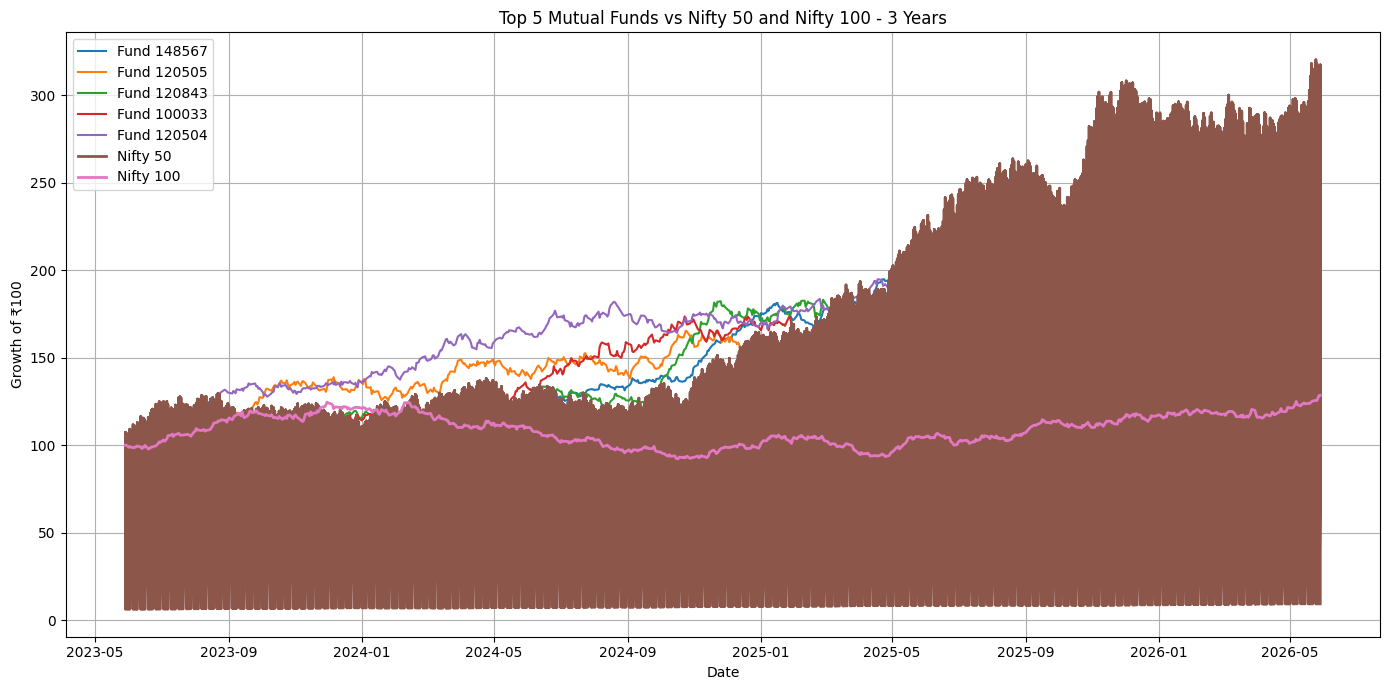

In [174]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

# Top 5 funds
for code in top5_codes:
    plt.plot(
        normalized_data.index,
        normalized_data[code],
        label=f"Fund {code}"
    )

# Nifty 50
plt.plot(
    normalized_data.index,
    normalized_data['NIFTY50'],
    label='Nifty 50',
    linewidth=2
)

# Nifty 100
plt.plot(
    normalized_data.index,
    normalized_data['NIFTY100'],
    label='Nifty 100',
    linewidth=2
)

plt.title("Top 5 Mutual Funds vs Nifty 50 and Nifty 100 - 3 Years")
plt.xlabel("Date")
plt.ylabel("Growth of ₹100")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "benchmark_comparison.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [170]:
tracking_error_df = tracking_error_df.merge(
    expense_data[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

tracking_error_df = tracking_error_df[
    [
        'amfi_code',
        'scheme_name',
        'tracking_error_nifty50',
        'tracking_error_nifty100'
    ]
]

print(tracking_error_df)

   amfi_code                                        scheme_name  \
0     148567      Mirae Asset Large Cap Fund - Regular - Growth   
1     120505           ICICI Pru Midcap Fund - Regular - Growth   
2     120843             Kotak Flexicap Fund - Regular - Growth   
3     100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   
4     120504          ICICI Pru Bluechip Fund - Direct - Growth   

   tracking_error_nifty50  tracking_error_nifty100  
0                0.196840                 0.187871  
1                0.237186                 0.232534  
2                0.210496                 0.206427  
3                0.229304                 0.224853  
4                0.201293                 0.187197  


In [171]:
tracking_error_df.to_csv(
    "tracking_error.csv",
    index=False
)

print("Tracking error calculated successfully!")
print("File: tracking_error.csv")

Tracking error calculated successfully!
File: tracking_error.csv


## Task 8: Benchmark Comparison - Result

In this task, I compared the top 5 mutual funds with Nifty 50 and Nifty 100 for the last 3 years.

The performance was compared by taking the starting value as 100. I also calculated the tracking error of the top 5 funds against both benchmarks.

The benchmark comparison chart was created and saved as `benchmark_comparison.png`.

The tracking error results were also saved in `tracking_error.csv`.

Task 8 is completed successfully.